Cargamos los datos del notebook anterior:

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

! cd /content/drive/MyDrive/practica_NPL

path = "/content/drive/MyDrive/practica_NPL"


data_book_limpia = pd.read_csv(f'{path}/corpus_final_limpio.csv')  # el que guardaste en Notebook 2
data_book_limpia = data_book_limpia.dropna(subset=["text_preprocessed", "sentiment"]).reset_index(drop=True)

print(data_book_limpia[["text_preprocessed", "sentiment"]].head())
data_book_limpia["sentiment"].value_counts()

                                   text_preprocessed  sentiment
0  main character diane hard identify entire stor...          0
1  several page picture cut scissor also underlin...          0
2  spend forty audio book make expensive shell no...          1
3  wow one good book read quite base actual event...          1
4  say first buy book think worth not worth not k...          0


,count
sentiment,
1,2495
0,2493


Una vez hemos terminado de procesar el corpus, pasamos a la creación de un modelo predictor del sentimiento. Para ello, se hará primeramente la parte clave: transformación del corpus en vectores numéricos. Como sabemos, los modelos solo pueden trabajar con números, y no con texto. En consecuencia, el texto normalizado y procesado de cada review deberá tansformarse de alguna manera a un vector numérico para la extracción de las características predictoras (Bag-of-words). Una vez hecho esto, tan solo quedará entrenar el modelo de clasificación binaria que elijamos de ML o DL.
# 1. Separación de train y test:

Como se mencionó en el notebook pasado, es importante hacer esta división de train y test previo a cualquier extracción de features, pues producirían un data leakage.


In [ ]:
#COMO HECHO EN CADA MODULO:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( data_book_limpia["text_preprocessed"], data_book_limpia["sentiment"],
    train_size=0.75,
    test_size=0.25,
    random_state=42,
    stratify=data_book_limpia["sentiment"],
    shuffle=True)

y_train.value_counts(), y_test.value_counts() # Para comprobar que se hace bien la estratificación y el porcentaje de division

(sentiment
 1    1871
 0    1870
 Name: count, dtype: int64,
 sentiment
 1    624
 0    623
 Name: count, dtype: int64)


# 2. Extracción de features:

Para ello, existen varios modelos/procesos a seguir. Los más simples, como el one-hot encodigin o el countvectoriser, se descartarán por su simplifidad incapaz de detectar verdaderamente una relación sematica entre las palabras. Es por ello que utilizamos, o TF-IDF más utilizados en modelos ML (mide sufrecuencia en relación a la rareza en el documento), o wordembedding, asociados a modelos de DL.

### **Comenzamos con ML: tfidVectorizer + Logistic Regression (modelo de clasificación binaria)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


**tfidVectorizer**

In [ ]:
#COMO VISTO EN CLASE:

cv = TfidfVectorizer(
    max_df=0.95,
    min_df=3,
    max_features=5000,
    strip_accents='ascii',
    ngram_range=(1, 2)
)
cv.fit(X_train)

TfidfVectorizer(max_df=0.95, max_features=5000, min_df=3, ngram_range=(1, 2),
                strip_accents='ascii')

In [ ]:
print(list(cv.vocabulary_.items())[:20])

[('great', np.int64(1953)), ('never', np.int64(2904)), ('receive', np.int64(3640)), ('fully', np.int64(1793)), ('agree', np.int64(79)), ('reviewer', np.int64(3759)), ('give', np.int64(1864)), ('detailed', np.int64(1184)), ('glow', np.int64(1882)), ('description', np.int64(1170)), ('book', np.int64(441)), ('important', np.int64(2188)), ('work', np.int64(4897)), ('address', np.int64(47)), ('real', np.int64(3609)), ('challenge', np.int64(737)), ('develop', np.int64(1190)), ('model', np.int64(2812)), ('environment', np.int64(1429)), ('agile', np.int64(77))]


In [ ]:
print("Vocababulario size:", len(cv.vocabulary_))

Vocababulario size: 5000


Se han elegido  los siguientes parametros:
- max_df: que se elimnen las palabras que aparecen en mas del 95% de las filas (como puede ser book)
- min_df: también que se elimen las que aparezcan solo en tres filas, y por tanto, no den información util.
- Se ha decidido que haya como maximo 5000 feautures, mayor al numero de filas ya que se usan tanto palabras sueltas, como en parejas

Una vez entrenado con los datos de train, le hacemos la misma transformación al dataset de train como de test:

In [ ]:
X_train_tfidf = cv.transform(X_train)
X_test_tfidf = cv.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(3741, 5000)
(1247, 5000)


<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-668009301.py:20: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi^2$', fontsize=26)
/tmp/ipython-input-668009301.py:22: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Top {} $\chi^2$ score for each word in the training set'.format(i), fontsize=20)


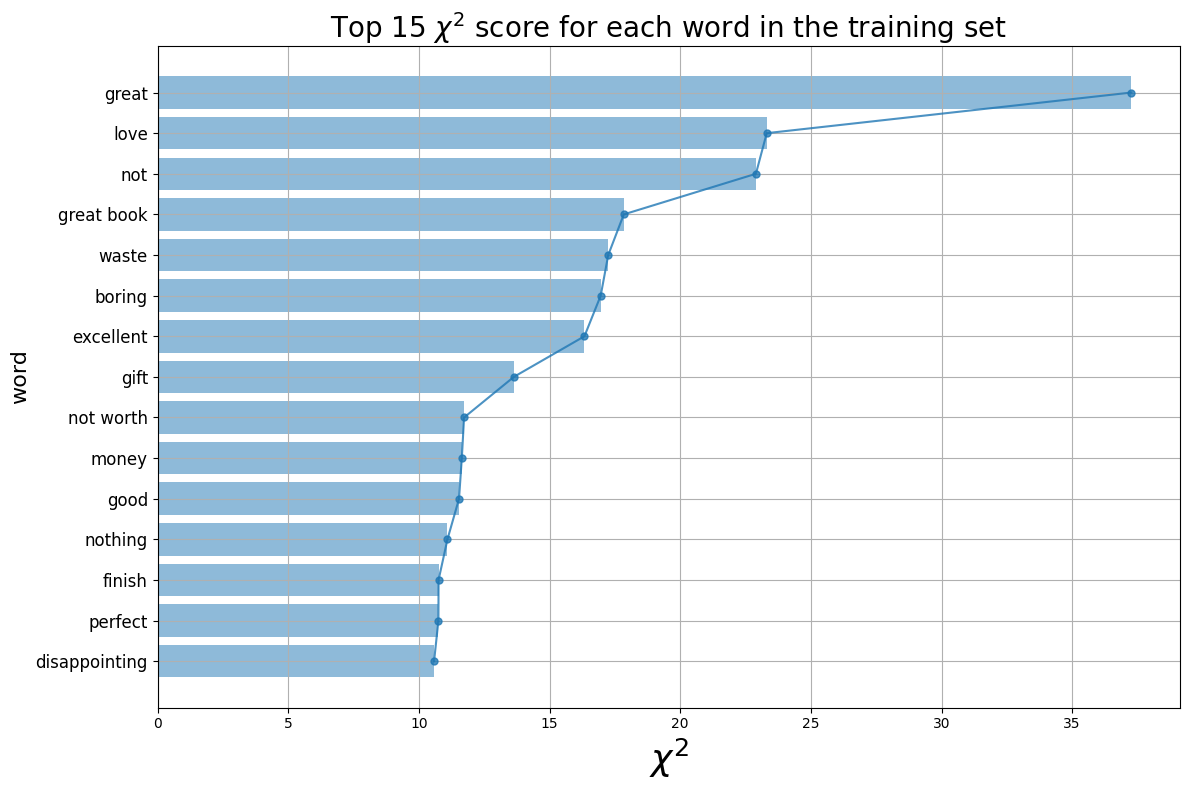

In [ ]:
# Para chequear como hemos visto en clase:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2

i = 15
y_pos = (y_train == 1).astype(int)
chi2_scores = chi2(X_train_tfidf, y_pos)[0]
scores = list(zip(cv.get_feature_names_out(), chi2_scores))
sorted_scores = sorted(scores, key=lambda x:x[1])
topchi2 = list(zip(*sorted_scores[-i:]))
x = range(len(topchi2[1]))
labels = topchi2[0]

plt.figure(figsize=(12, 8))
plt.barh(x,topchi2[1], align='center', alpha=0.5)
plt.plot(topchi2[1], x, '-o', markersize=5, alpha=0.8)
plt.yticks(x, labels, fontsize=12)
plt.xlabel('$\chi^2$', fontsize=26)
plt.ylabel('word', fontsize=16)
plt.title('Top {} $\chi^2$ score for each word in the training set'.format(i), fontsize=20)
plt.grid()
plt.tight_layout()
plt.show()

Estos serán los terminos que están más asociados s una de las clases, pero no se sabe si es a la clas epositiva o negativa.

###**Logistic Regression**
Para buscar el mejor modelo dentro del logistic regression, haremos una validación cruzada (gridsearchCV) para encontrar el valor óptimo de hiperparámetro C. Esto ya se vio en el modelo de ML.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

lr = LogisticRegression(solver="lbfgs", max_iter=1000)

c_vector = np.logspace(-3, 3, 7)
param_grid = {"C": c_vector}
cv_lr=StratifiedKFold(n_splits=5, shuffle=True, random_state=0) # Para cerciorar que se produce un muestreo barajado y estratificado por cada fold

grid = GridSearchCV(estimator=lr, param_grid=param_grid, cv=cv_lr, scoring="accuracy", verbose=2, n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
best mean cross-validation score: 0.838
best parameters: {'C': np.float64(1.0)}


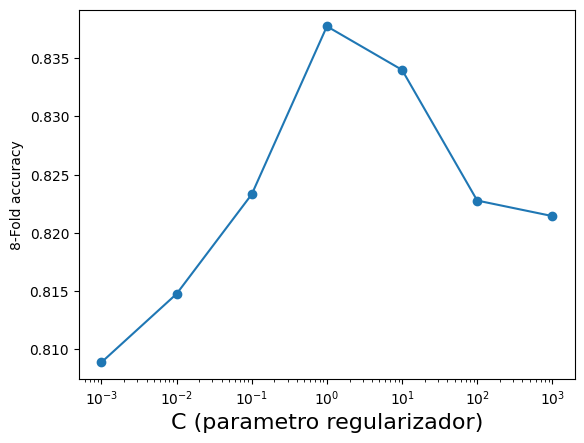

In [ ]:
scores = np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(c_vector,scores,'-o')
plt.xlabel('C (parametro regularizador)',fontsize=16)
plt.ylabel('8-Fold accuracy')
plt.show()

Como se puede ver, obtenemos la forma de la curva esperada. Para valores de C muy pequeños, donde el modeloe stá muy regularizado, existe un underfitting, y por tanto la accuracy es muy baja. Esto va mejorando segñun aumenta C, hasta llegar al punto óptimo donde c=1, y la accuracy llega a su máximo. Si c ya toma valores mayores, existe muy pocaregularización y por tanto, se produce el overfitting, cayendo el rendimiento.

In [ ]:
c_optimo = grid.best_params_['C']
lr_best = LogisticRegression(C = c_optimo, solver="lbfgs", max_iter=1000).fit(X_train_tfidf,y_train)

y_pred_lr = lr_best.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Test accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification report:\n", classification_report(y_test, y_pred_lr))

Test accuracy: 0.8380112269446672
Confusion matrix:
 [[518 105]
 [ 97 527]]
Classification report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84       623
           1       0.83      0.84      0.84       624

    accuracy                           0.84      1247
   macro avg       0.84      0.84      0.84      1247
weighted avg       0.84      0.84      0.84      1247



### **Seguimos con ML: COUNT VECTORIZER + SVM**
Siguiendo con otros modelos visto también en el módulo ML, aplicamos el  SVM como segunda propuesta de modelo. Se ha decidido este modelo, pues ya tenemos los datos con vectores, y estos modelos deben su nombre a maquinas de vectores de soporte. Como nuestro caso es de clasificación binario, utilizaremos un SVC. Al igual que antes, se hará un CV para encontrar el valor óptimo del parámetro C, como se vio en el módulo de ML.

In [ ]:
from sklearn.svm import LinearSVC

svm_clas = LinearSVC(dual="auto", random_state=5)

c_vector = np.logspace(-3, 3, 7)
param_grid = {"C": c_vector}

grid = GridSearchCV(estimator=svm_clas, param_grid=param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=5), scoring="accuracy", verbose=2, n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))


Fitting 5 folds for each of 7 candidates, totalling 35 fits
best mean cross-validation score: 0.845
best parameters: {'C': np.float64(0.1)}


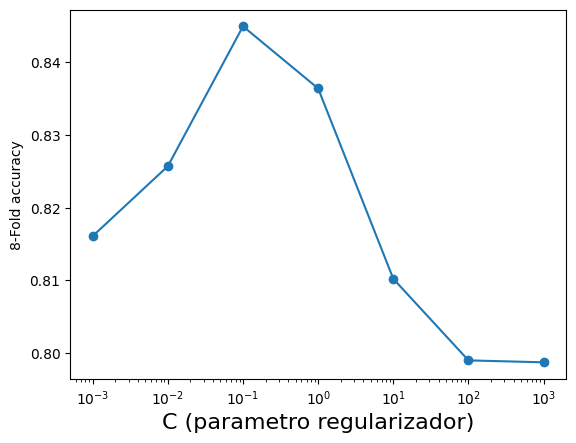

In [ ]:
scores = np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(c_vector,scores,'-o')
plt.xlabel('C (parametro regularizador)',fontsize=16)
plt.ylabel('8-Fold accuracy')
plt.show()

En este caso, volvemos a conseguir de nuevo la curva esperada, con un pico claro en C, que dará las mejore sprestaciones a nuestro modelo SVM.

In [ ]:
c_optimo = grid.best_params_['C']
svm_best  = LinearSVC(C = c_optimo, dual="auto", random_state=000).fit(X_train_tfidf,y_train)

y_pred_svm = svm_best.predict(X_test_tfidf)


In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.842822774659182
Confusion matrix:
 [[523 100]
 [ 96 528]]
Classification report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       623
           1       0.84      0.85      0.84       624

    accuracy                           0.84      1247
   macro avg       0.84      0.84      0.84      1247
weighted avg       0.84      0.84      0.84      1247



Se concluye, que ambos modelos presentados, propios de ML, presentan muy buenas prestaciones, siendo un poco mejor "SVM", en cuanto a precision y los verdaderos positivos y negativos son mayores. Tmabién es inferior los falsos negativos y falsos positivos como era de esperar. Sin embargo, cabe destacar que ambos no llevan apenas tiempo de entreno. Por último, se observa que no solo se consigue buenas prestaciones, sino que no se produce overfitting en ningun caso, siendo el valor del accuracy en ambos dtaset (entrenamiento y test) muy similar y alto.
Por tanto, nos quedariamos con SVM por una mejora mínima.

### **Terminamos con DL: word embedding (word2vec)**

Para terminar, hacemos el como último paso, lo pedido para el primer notebook: hacer un wordembedding, visualizarlo.

Cabe destacar que dentro de los word embedding estudiados, existen dos métodos: word2vec y Fasttext. Se utiliza el primero, pues es capaz de abstraer el contexto (relación sematica y contextuales), mientras que el segundo capta mayoritariamenterelación morfologíaca entre las palabras que puede ser de poca utilidad en este caso. Estos métodos se suelen utilizar más con modelo de DL, pero también puede hacerse con modelo ML.

#### 1. Creación word embeddings

In [ ]:
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.1 MB/s eta 0:00:00


In [ ]:
#COMO VISTO EN CLASE:

from matplotlib import cm
import multiprocessing
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
from sklearn.manifold import TSNE

In [ ]:
cores = multiprocessing.cpu_count() # Contamos el número de cores en el ordenador
print (cores)

2


In [ ]:
#preparamos la data para meter al modelo word2vec:
sentences  = data_book_limpia["text_preprocessed"].apply(lambda x: x.split()).tolist()

print("hay tantos frases que se van a vectorizar:", len(sentences))
print("Ejemplo:", sentences[0][:10])


hay tantos frases que se van a vectorizar: 4988
Ejemplo: ['main', 'character', 'diane', 'hard', 'identify', 'entire', 'story', 'anorexia', 'cut', 'overdone']


In [ ]:
w2v_model = Word2Vec(min_count=5,
                     window=5,
                     vector_size=200,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     sg=1,
                     workers=cores-1)

w2v_model.build_vocab(sentences, progress_per=10000)
print('Vocabulario compuesto por {} palabras'.format(len(w2v_model.wv.key_to_index)))

w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=20, report_delay=1)


Vocabulario compuesto por 6411 palabras


(3067118, 6582560)

In [ ]:
w2v_model.wv.most_similar("book", topn=10)

[('grandkid', 0.7422343492507935),
 ('read', 0.7269614338874817),
 ('bookclub', 0.70445716381073),
 ('preview', 0.7019229531288147),
 ('sophisticated', 0.6938053965568542),
 ('really', 0.6911582946777344),
 ('snarky', 0.6906663179397583),
 ('well', 0.6885616183280945),
 ('scribble', 0.6805119514465332),
 ('preachy', 0.6802978515625)]

In [ ]:
w2v_model.wv.most_similar("good")

[('well', 0.6615054607391357),
 ('lot', 0.6569332480430603),
 ('diabete', 0.6475080847740173),
 ('great', 0.6474488973617554),
 ('snarky', 0.6403912901878357),
 ('breaker', 0.6401767730712891),
 ('like', 0.639874279499054),
 ('ultra', 0.638217568397522),
 ('book', 0.6367620825767517),
 ('bookclub', 0.6348475217819214)]

In [ ]:
w2v_model.wv.most_similar("boring")

[('dnf', 0.7873549461364746),
 ('uninteresting', 0.7528982758522034),
 ('dud', 0.7348638772964478),
 ('forgettable', 0.7230328917503357),
 ('unimaginative', 0.6920690536499023),
 ('trite', 0.6914226412773132),
 ('mish', 0.68233722448349),
 ('cornwell', 0.679351806640625),
 ('unfinished', 0.6718940138816833),
 ('plod', 0.6680477857589722)]

Se puede observar que el modelo funciona correctamente, pues las palabras similares a "book", que engloba el tema principal de las reviews se asemeja tanto a adjetivos positivos y negativos (depende del sentimienot de la review) como a palabras en clara conexion como "read" o "bookclub". También destaca"grandkid" como palabra que, aunque en un primer momento puede parecer inconexa, puede venir de reviews en las que se lo recomendaría a mi nieto, o de abuelos, más propensos a la lectura por la época donde han vivido, compran más libros como regalos.
Por otro lado, a nivel de sentimiento positivo, encontramos palabras muy acordes como "well", "lot", "breaker" "like", aunque es cierto que "diabete" no parece que tenga relación. Probablemente se debe a pequeños errores que se producen en el modelo, al estar trabajando con solo una pequeña muestra, o tal vez exista una explicación que se escape a nuestro entendimiento.
Por último, en cuanto reviews con sentimiento negativo, podemos ver que la más relación es "dnf", abreviatura de "did not finish", lo cual tiene todo el sentido en este sentimiento. También destacan "uninteresting", "forgettable" o "dud" que significa falso, "plod" cuando algo es lento y pesado. También destaca "corwell" que parece relacionado con el nombre de la autora "patricia cornwell" (el nombre de patricia aparecía si cambiaba los aprametros del modelo word2vec). De nuevo, puede que haya un error en el modelo, o puede que efectivamente, no hayan gustado sus libros.


#### 2. Visualización

In [ ]:
words_to_plot_sentimiento = ["good", "bad", "boring", "interesting", "excellent"]
words_to_plot_tema = ["book", "author", "story", "chapter", "reader"]
words_to_plot_negaciones = ["not", "never", "always", "sometimes"]

embedding_clusters = []
word_clusters = []
for word in words_to_plot:
    embeddings = [w2v_model.wv[word]]
    words = [word]
    for similar_word, _ in w2v_model.wv.most_similar(word, topn=10):
        words.append(similar_word)
        embeddings.append(w2v_model.wv[similar_word])
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

In [ ]:
tsne_model_2d = TSNE(perplexity=8, n_components=2, init='pca', n_iter=3500, random_state=32)

In [ ]:
embedding_clusters = np.array(embedding_clusters)
n, m, k = embedding_clusters.shape

In [ ]:
embeddings_2d = np.array(tsne_model_2d.fit_transform(embedding_clusters.reshape(n * m, k))).reshape(n, m, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


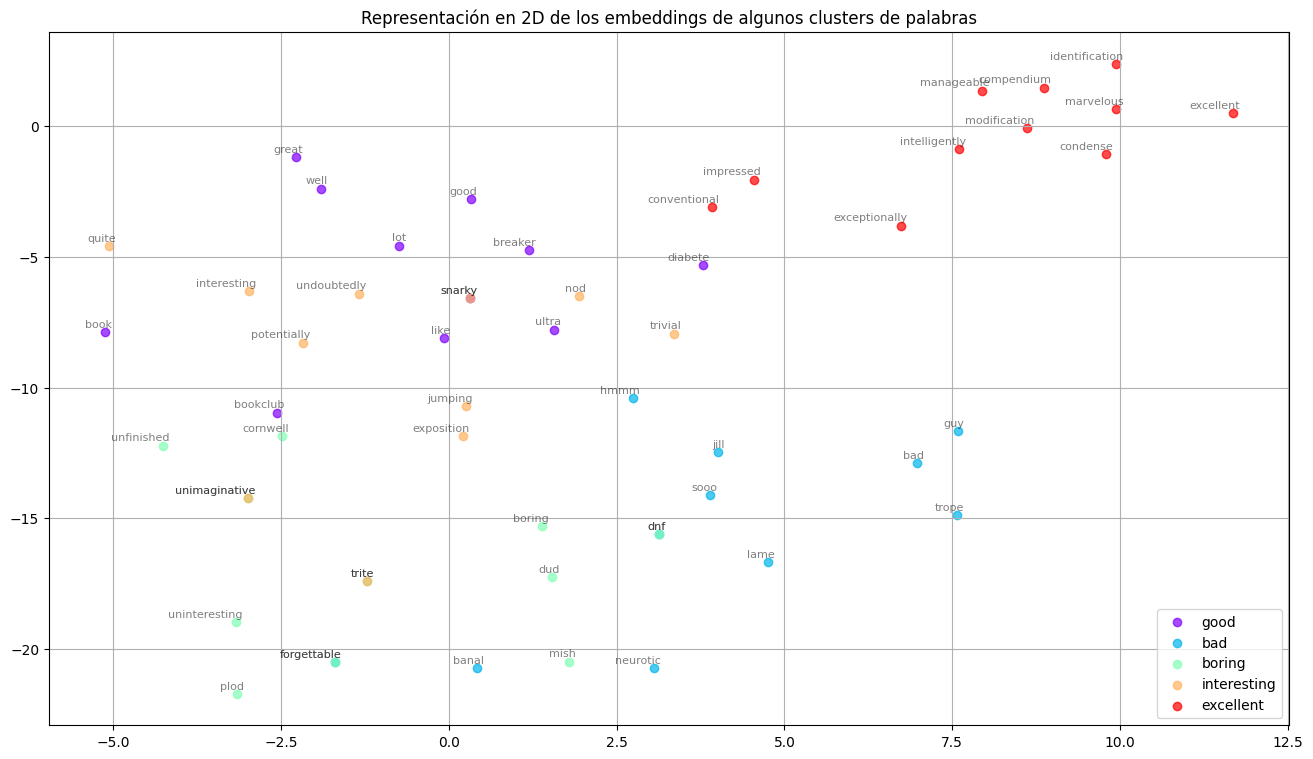

In [ ]:
def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
    plt.figure(figsize=(16, 9))
    colors = cm.rainbow(np.linspace(0, 1, len(labels)))
    for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
        x = embeddings[:,0]
        y = embeddings[:,1]
        plt.scatter(x, y, c=[color], alpha=a, label=label)
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                         textcoords='offset points', ha='right', va='bottom', size=8)
    plt.legend(loc=4)
    plt.grid(True)
    plt.title('Representación en 2D de los embeddings de algunos clusters de palabras')
    # plt.savefig("f/г.png", format='png', dpi=150, bbox_inches='tight')
    plt.show()


tsne_plot_similar_words(words_to_plot_sentimiento, embeddings_2d, word_clusters)

Se puede ver perfectamente, que estas palabras tan significativas del sentimiento, están dividias en 3 pequeños clusters. Aunque es cierto, que lso cluster no se diferencian perfectamenet, pues hay que pensr que muchas veces las reviews no son tan polarizadas, si que vemos que palabras similares como good and interesting se entremezclan en la esquina superior izquierda, mientras que las oalabras similares a boring y bad se mezclan por debajo de las anteriores. Por otro lado, más separados, vemos las palabras en relación a "excellent", que crearian otro cluster/categoría al tratarse de sentimiento más polarizado, y no tan "entre medias" como puede ser good and bad.

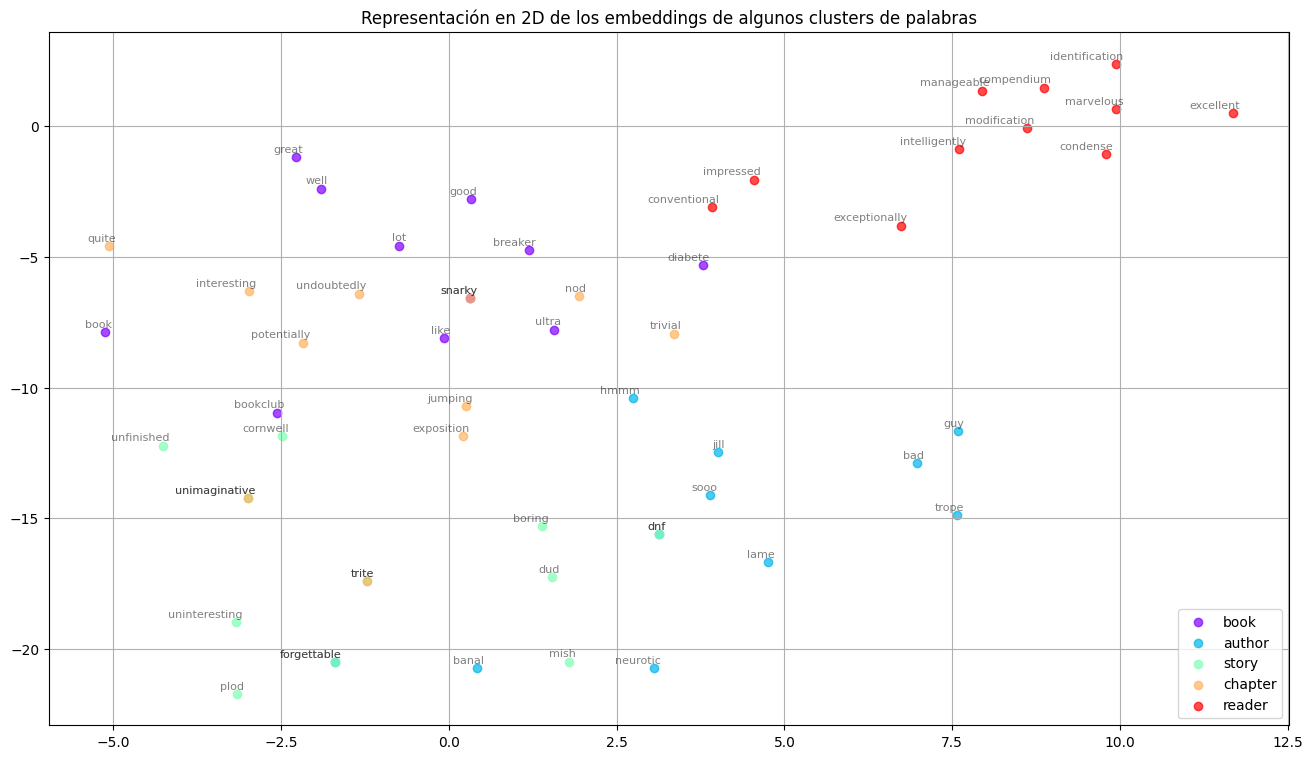

In [ ]:
tsne_plot_similar_words(words_to_plot_tema, embeddings_2d, word_clusters)

En este caso, con palabras en relación al tema principipal de las reviews y no del snetimiento, vemos menos diferenciados os clusters. Veriamos un "cluster" bastante esparcidos con las palabras similares a aquellas sobre el propio libro =book, author, stroy, chapter", mientras que completamente separado etsaría el "lector".

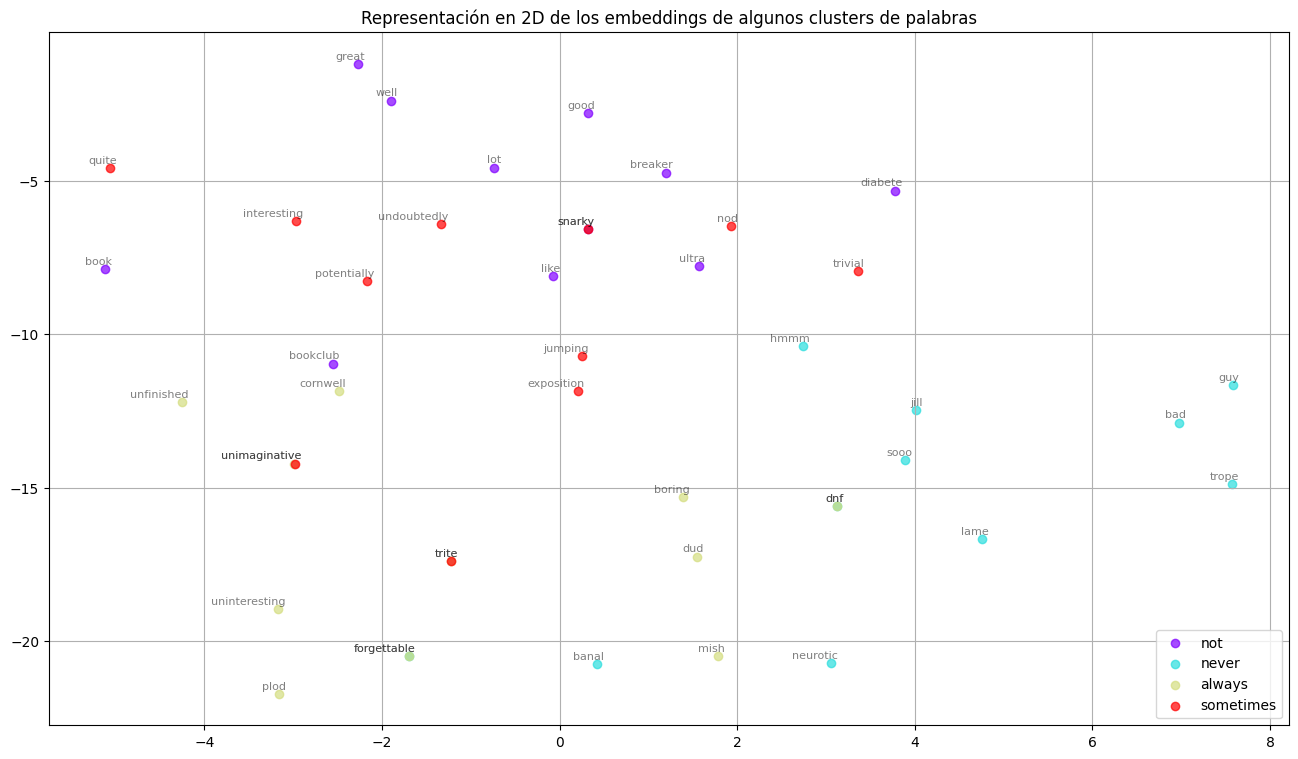

In [ ]:
tsne_plot_similar_words(words_to_plot_negaciones, embeddings_2d, word_clusters)

En cuanto a palabras funcionales, vemos que existen dos grupos diferencias aunque internamente cada uno este muy esparcido. Por ejemplo, palabras similares a "always", "never" que son más contundentes y decisivas, aunque contrarias, se encuentarn en el mismo clusters, aunque seapradas cada una en un extremos. Por otro lado, palabras similares asoemtimes, or not, las cuales no son tan discrimnatorias y decisivas formarian otro cluster en la esquina superior izquierda.

Me habria gustado, utilizar ahora este modelo creado de word2vec, junto al tokenizer de tensorflow para ser utilizados en un modelo de DL. Sin embargo, por falta de tiempo, nos quedamos con lo estrictamente pedido en el enunciado de la práctica.

Por último, guardaremos cada uno de los modelos, para poder utilizarlos en el siguiente notebook:

In [ ]:
import pickle

models_path = f"{path}/models"
os.makedirs(models_path, exist_ok=True)

with open(f"{models_path}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(cv, f)

with open(f"{models_path}/logreg_tfidf.pkl", "wb") as f:
    pickle.dump(lr_best, f)

with open(f"{models_path}/svm_tfidf.pkl", "wb") as f:
    pickle.dump(svm_best, f)

In [67]:
# se guardan tambien los datsets de train y test para luego aplicar el vectorizador que hemos guardado:

train_df = pd.DataFrame({"text_preprocessed": X_train, "sentiment": y_train})
test_df = pd.DataFrame({"text_preprocessed": X_test, "sentiment": y_test})

train_df.to_csv(f"{path}/train_df.csv", index=False)
test_df.to_csv(f"{path}/test_df.csv", index=False)